In [1]:
pip install pandas numpy scikit-learn lime matplotlib openpyxl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=819848639bcb382a77f9ec3517bcf0a74a4dac249b155e597a62714d7ec69671
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [2]:
from google.colab import files
uploaded = files.upload()

Saving VD_HCC.xlsx to VD_HCC.xlsx


Số lượng bản ghi sau khi xóa trùng lặp: 880
Phát hiện giá trị thiếu. Đang tiến hành điền bằng giá trị trung vị...
Bắt đầu chạy đánh giá ngẫu nhiên 30 lần với LIME...
Đã hoàn thành 5/30 lần lặp...
Đã hoàn thành 10/30 lần lặp...
Đã hoàn thành 15/30 lần lặp...
Đã hoàn thành 20/30 lần lặp...
Đã hoàn thành 25/30 lần lặp...
Đã hoàn thành 30/30 lần lặp...


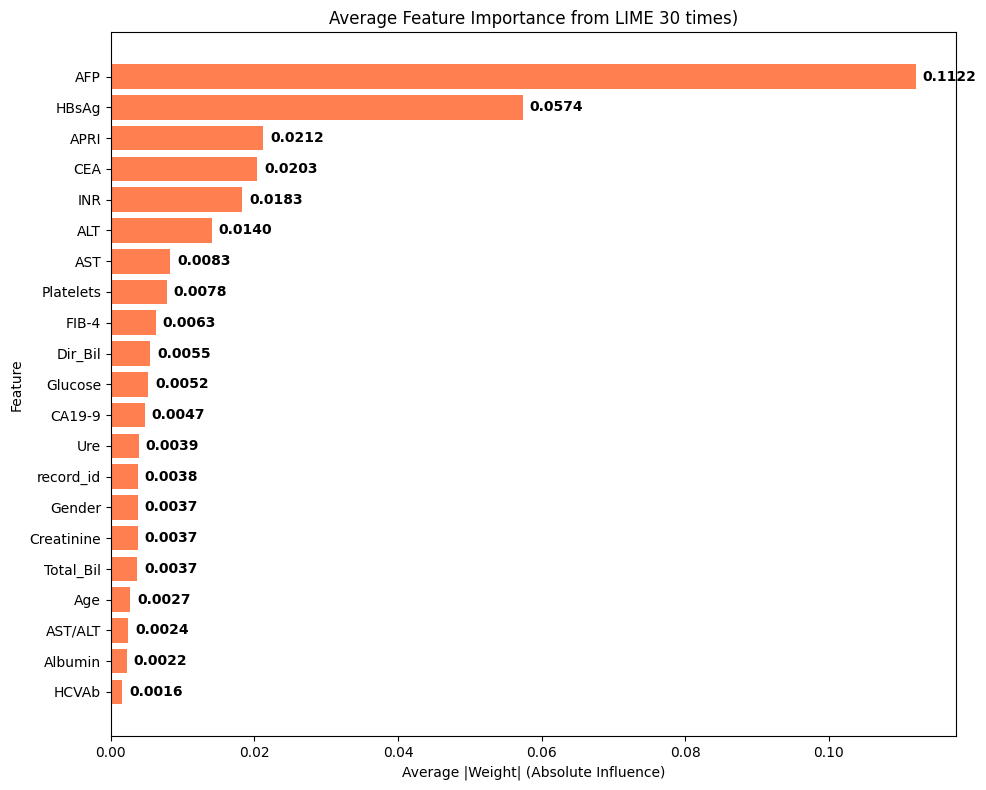

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import lime
import lime.lime_tabular

# 1. TẢI VÀ CHUẨN BỊ DỮ LIỆU
df = pd.read_excel('VD_HCC.xlsx')

# CHỐNG RÒ RỈ: Loại bỏ bản ghi trùng lặp
df = df.drop_duplicates()
print(f"Số lượng bản ghi sau khi xóa trùng lặp: {len(df)}")

# XỬ LÝ GIÁ TRỊ THIẾU (NaN): Điền giá trị thiếu bằng trung vị (median)
if df.isnull().values.any():
    print("Phát hiện giá trị thiếu. Đang tiến hành điền bằng giá trị trung vị...")
    df = df.fillna(df.median())

TARGET_COLUMN = 'label'
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

# Loại bỏ các đặc trưng có giá trị không đổi trên toàn bộ tập dữ liệu
constant_features_global = [col for col in X.columns if X[col].nunique() == 1]
if constant_features_global:
    print(f"Loại bỏ đặc trưng không đổi toàn cục: {constant_features_global}")
    X = X.drop(columns=constant_features_global)

original_feature_names = X.columns.tolist()
original_feature_to_index = {name: idx for idx, name in enumerate(original_feature_names)}

# 2. CẤU HÌNH VÒNG LẶP
n_iterations = 30
test_size = 0.2
global_lime_importance = np.zeros((n_iterations, len(original_feature_names)))

print(f"Bắt đầu chạy đánh giá ngẫu nhiên {n_iterations} lần với LIME...")

# 3. TIẾN HÀNH LẶP 30 LẦN
for i in range(n_iterations):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=i)

    # Kiểm tra đặc trưng không đổi trong Train của lần lặp này
    constant_features_in_train = [col for col in X_train.columns if X_train[col].nunique() == 1]

    curr_X_train = X_train.drop(columns=constant_features_in_train) if constant_features_in_train else X_train.copy()
    curr_X_test = X_test.drop(columns=constant_features_in_train) if constant_features_in_train else X_test.copy()

    feat_names_iter = curr_X_train.columns.tolist()

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(curr_X_train)
    X_test_scaled = scaler.transform(curr_X_test)

    model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(X_train_scaled, y_train)

    # QUAN TRỌNG: discretize_continuous=False để tránh lỗi 'scale must be positive'
    explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_train_scaled,
        feature_names=feat_names_iter,
        class_names=['0', '1'],
        mode='classification',
        discretize_continuous=False,
        random_state=i
    )

    iter_weights = np.zeros(len(feat_names_iter))
    n_samples = X_test_scaled.shape[0]

    for j in range(n_samples):
        exp = explainer.explain_instance(
            data_row=X_test_scaled[j],
            predict_fn=model.predict_proba,
            num_features=len(feat_names_iter)
        )
        # Lấy trọng số cho class 1
        for feat_idx, weight in exp.local_exp[1]:
            iter_weights[feat_idx] += np.abs(weight)

    iter_weights /= n_samples

    # Ánh xạ về mảng gốc
    temp_weights = np.zeros(len(original_feature_names))
    for k, name in enumerate(feat_names_iter):
        temp_weights[original_feature_to_index[name]] = iter_weights[k]

    global_lime_importance[i, :] = temp_weights

    if (i + 1) % 5 == 0:
        print(f"Đã hoàn thành {i + 1}/{n_iterations} lần lặp...")

# 4. TỔNG HỢP VÀ TRỰC QUAN HÓA
final_importance = np.mean(global_lime_importance, axis=0)
importance_df = pd.DataFrame({
    'Feature': original_feature_names,
    'LIME_Importance': final_importance
}).sort_values(by='LIME_Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(importance_df['Feature'], importance_df['LIME_Importance'], color='coral')
ax.bar_label(bars, fmt='%.4f', padding=5, fontweight='bold')
ax.set_title(f"Average Feature Importance from LIME {n_iterations} times)")
plt.xlabel('Average |Weight| (Absolute Influence)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()